## 1. RGB (Red, Green, Blue)


In [1]:
# preparar entorno
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

def mostrar(imagenes, titulos, cmap=None, figsize=None):
    """Muestra una lista de imágenes en una fila, cada una con su título.
    Si `cmap` es None se asume color (RGB); si es 'gray' se fuerza escala de grises.
    """
    n = len(imagenes)
    figsize = figsize or (4 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, titulo in zip(axes, imagenes, titulos):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap or "gray")
        else:
            ax.imshow(img)
        ax.set_title(titulo)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def mostrar_canales(canales, nombres, cmap="gray"):
    """Muestra cada canal de una imagen multicanal como un mapa de intensidad."""
    mostrar(list(canales), nombres, cmap=cmap)

print("Entorno listo.")

Entorno listo.


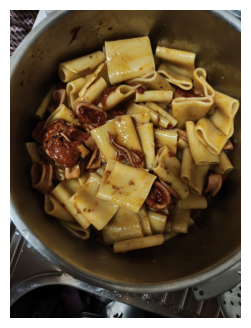

In [5]:
# Elegir la imagen
from PIL import Image
img_color = Image.open ("./pasta.jpg")
plt.figure(figsize=(4,4))
plt.imshow(img_color)
plt.axis("off")
plt.show()


## 2. HSV / HSL (Hue, Saturation, Value / Lightness)


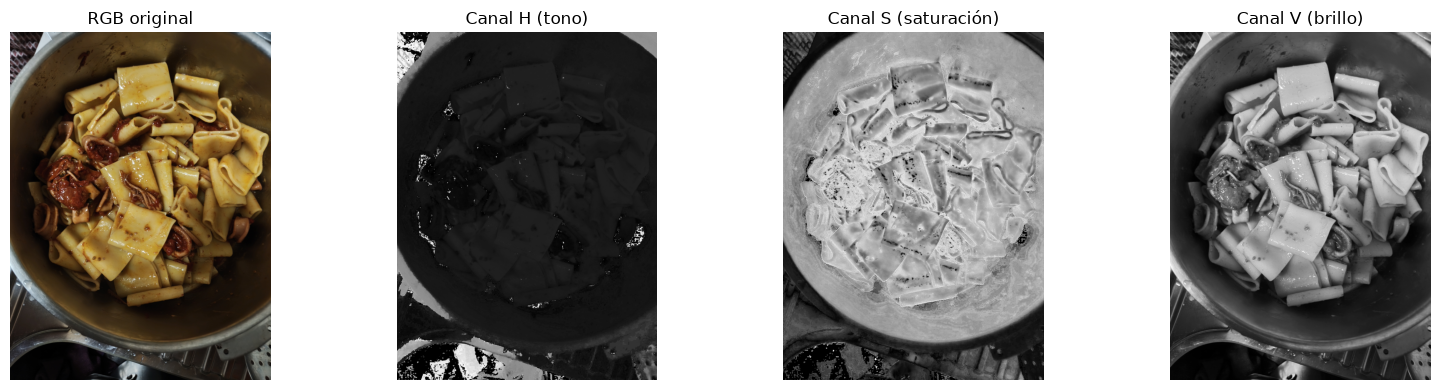

In [6]:
# convertir imagen RGB in HSV/HLS con OpenCV
img_color = Image.open ("./pasta.jpg")
img_color = np.array(img_color)
img_hsv = cv2.cvtColor(img_color, cv2.COLOR_RGB2HSV)
img_hls = cv2.cvtColor(img_color, cv2.COLOR_RGB2HLS)

H, S, V = cv2.split(img_hsv)
mostrar([img_color, H, S, V],
        ["RGB original", "Canal H (tono)", "Canal S (saturación)", "Canal V (brillo)"])


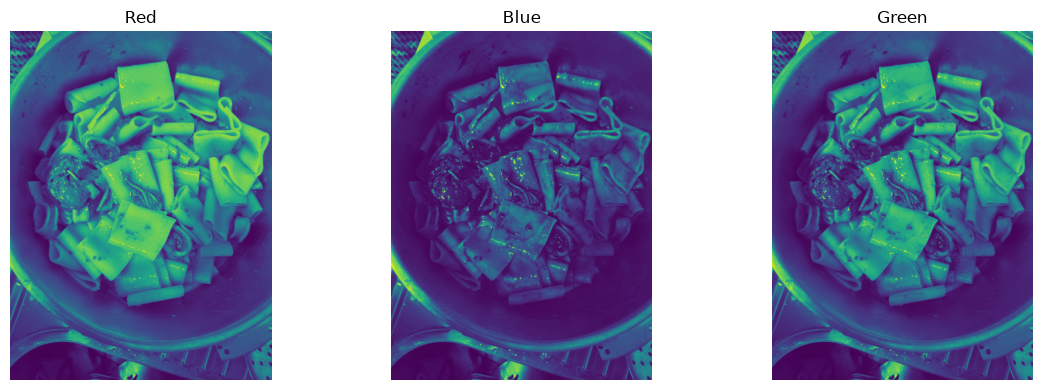

In [ ]:
# mostrar colores individuales
import cv2

img = cv2.imread("./pasta.jpg")
b, g, r = cv2.split(img)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(r)
ax1.set_title("Red")
ax1.axis("off")

ax2.imshow(b)
ax2.set_title("Blue")
ax2.axis("off")

ax3.imshow(g)
ax3.set_title("Green")
ax3.axis("off")

plt.tight_layout()

#plt.show()
#plt.imshow(b)
#plt.axis("off")
#plt.show()

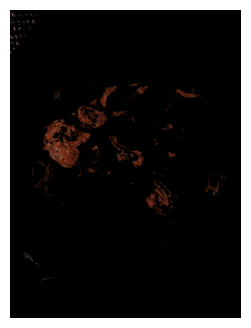

In [ ]:
# mostrar solo color rojo

#Si quieres detectar varios colores
#Rojo: (0, 50, 50) to (10, 255, 255) y (170, 50, 50) to (180, 255, 255)
#Verde: (35, 50, 50) to (85, 255, 255)
#Azul: (100, 50, 50) to (130, 255, 255)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("./pasta.jpg")

# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Máscara para rojo
mask1 = cv2.inRange(hsv, (0, 50, 50), (10, 255, 255))
mask2 = cv2.inRange(hsv, (170, 50, 50), (180, 255, 255))
mask = cv2.bitwise_or(mask1, mask2)

# Mantener solo rojo
red_only = cv2.bitwise_and(img, img, mask=mask)

# Mostrar
red_only_rgb = cv2.cvtColor(red_only, cv2.COLOR_BGR2RGB)
plt.imshow(red_only_rgb)
plt.axis("off")
plt.show()

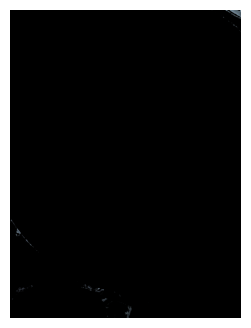

In [16]:
# mostrar solo color azul
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("./pasta.jpg")

# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Máscara para azul
mask = cv2.inRange(hsv, (100, 50, 50), (130, 255, 255))

# Mantener solo azul
blue_only = cv2.bitwise_and(img, img, mask=mask)

# Mostrar
blue_only_rgb = cv2.cvtColor(blue_only, cv2.COLOR_BGR2RGB)
plt.imshow(blue_only_rgb)
plt.axis("off")
plt.show()

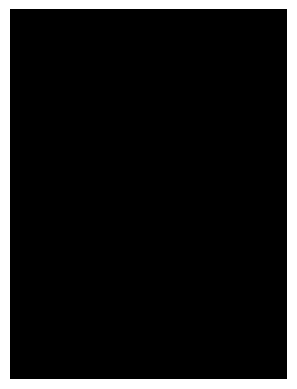

In [9]:
# mostrar solo color verde
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("./pasta.jpg")

# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Máscara para verde
mask = cv2.inRange(hsv, (35, 50, 50), (85, 255, 255))

# Mantener solo verde
green_only = cv2.bitwise_and(img, img, mask=mask)

# Mostrar
green_only_rgb = cv2.cvtColor(green_only, cv2.COLOR_BGR2RGB)
plt.imshow(green_only_rgb)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1020.0..1020.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1140.3946685248927].


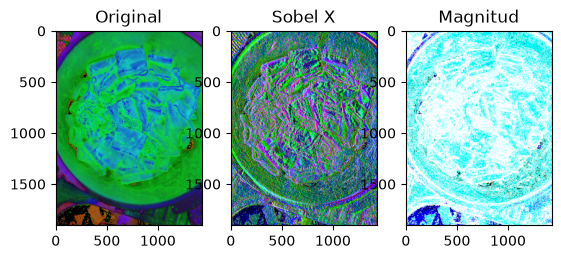

In [ ]:
# detection de bordes con Sobel

import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
sobel_x = cv2.Sobel(hsv, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(hsv, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

plt.subplot(1, 3, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")

plt.subplot(1, 3, 3)
plt.imshow(sobel_mag, cmap="gray")
plt.title("Magnitud")
plt.show()

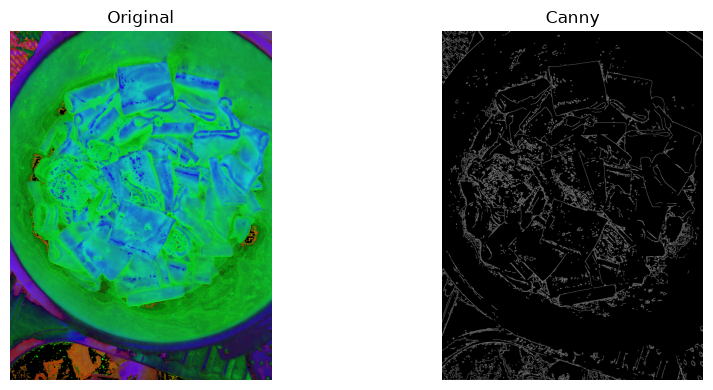

In [11]:
# detection de bordes con Canny
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Aplicar Canny
edges = cv2.Canny(hsv, 100, 200)

# Mostrar original y bordes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

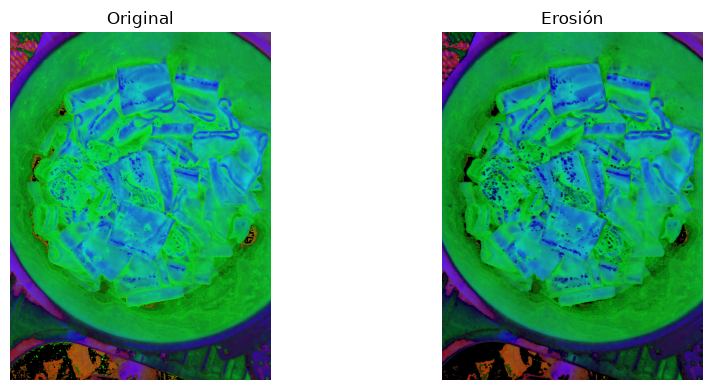

In [12]:
# Script para aplicar erosión a una imagen
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(hsv, kernel, iterations=1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosión")
plt.axis("off")

plt.tight_layout()
plt.show()

# Note: kernel = np.ones((3, 3), np.uint8) → erosión suave
#       kernel = np.ones((5, 5), np.uint8) → erosión más fuerte
#       iterations=1 → una pasada
#       iterations=3 → más erosión

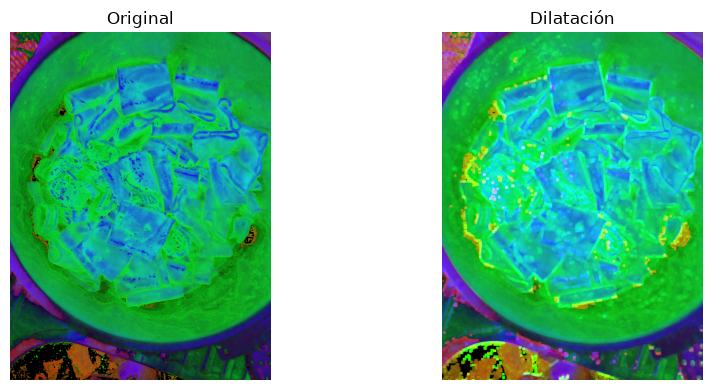

In [13]:
# script pra aplicar dilatación a una imagen
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

kernel = np.ones((5, 5), np.uint8)
dilation = cv2.dilate(hsv, kernel, iterations=3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dilation, cmap="gray")
plt.title("Dilatación")
plt.axis("off")

plt.tight_layout()
plt.show()

# Note: kernel = np.ones((3, 3), np.uint8) → dilatación suave
#       kernel = np.ones((5, 5), np.uint8) → dilatación más fuerte
#       iterations=1 → una pasada
#       iterations=3 → más dilatación

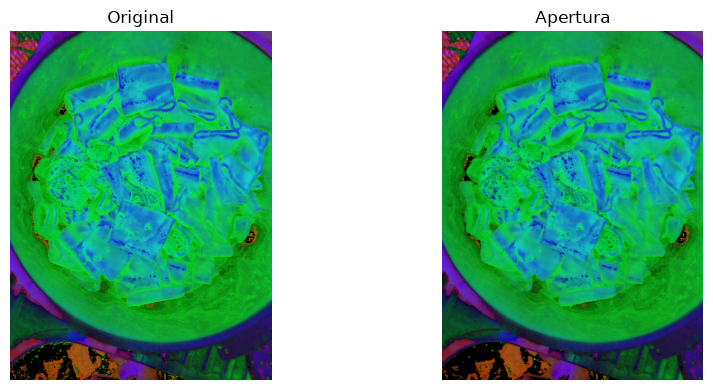

In [14]:
# script para aplicar apertura a una imagen
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(hsv, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(opening, cmap="gray")
plt.title("Apertura")
plt.axis("off")

plt.tight_layout()
plt.show()

#Qué hace: 
#           Primero hace erosión
#           Luego dilatación
#           Elimina detalles pequeños y ruido
#           Mantiene la forma principal

# Note: kernel = np.ones((3, 3), np.uint8) → suave
#       kernel = np.ones((5, 5), np.uint8) → más fuerte

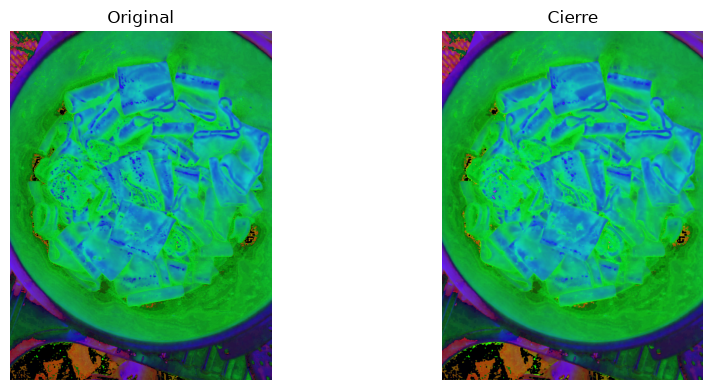

In [15]:
# script para cierre a una imagen

import cv2
import numpy as np
import matplotlib.pyplot as plt


# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

kernel = np.ones((5, 5), np.uint8)
closing = cv2.morphologyEx(hsv, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(hsv, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(closing, cmap="gray")
plt.title("Cierre")
plt.axis("off")

plt.tight_layout()
plt.show()

# Qué hace: 
#           Primero aplica dilatación
#           Luego aplica erosión
#           Rellena huecos pequeños
#           Une regiones cercanas

# Se utiliza para:
#                   cerrar pequeños agujeros
#                   rellenar grietas
#                   suavizar contornos de una máscara

# Ajustes comunes:
#                  kernel = np.ones((3, 3), np.uint8) → suave
#                  kernel = np.ones((5, 5), np.uint8) → más fuerte

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1140.3946685248927].


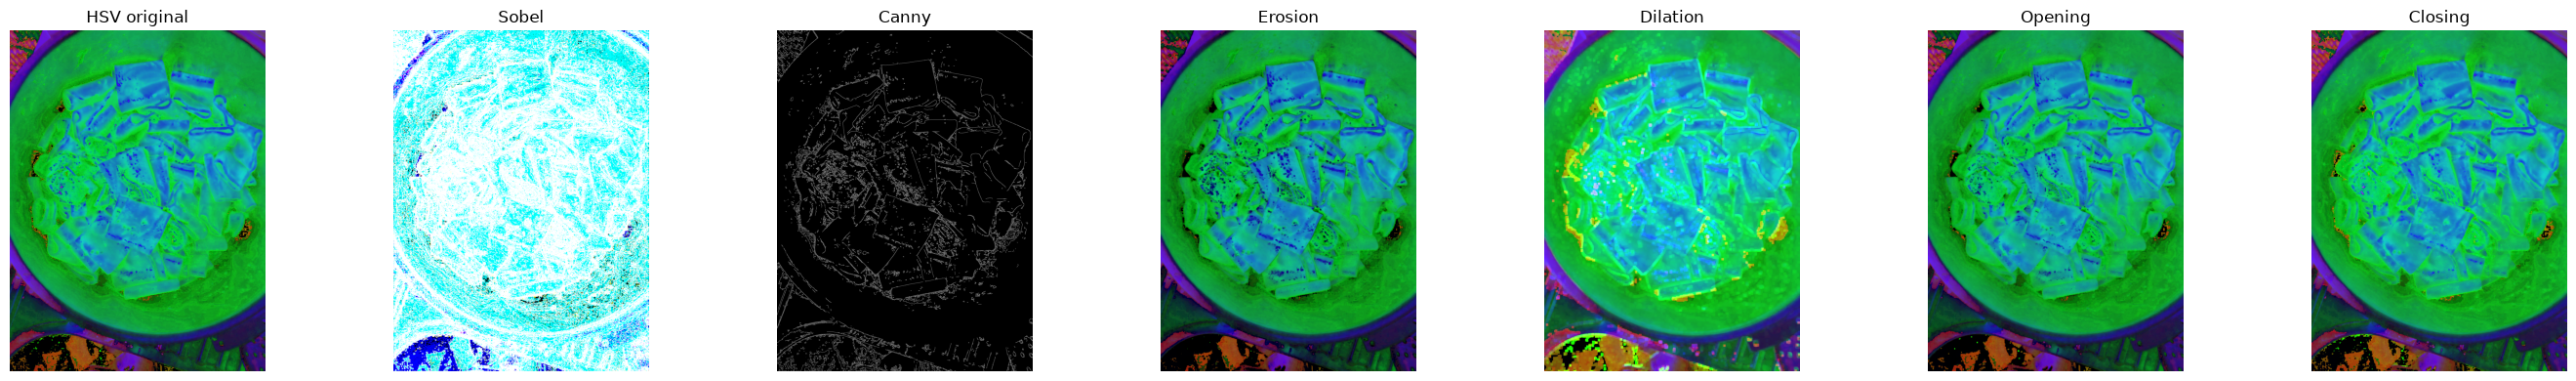

In [10]:
# resume


import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("./pasta.jpg")
# Convertir a HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

sobel_x = cv2.Sobel(hsv, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(hsv, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

edges = cv2.Canny(hsv, 100, 200)

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(hsv, kernel, iterations=1)
kernel = np.ones((5, 5), np.uint8)
dilation = cv2.dilate(hsv, kernel, iterations=3)
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(hsv, cv2.MORPH_OPEN, kernel)
kernel = np.ones((5, 5), np.uint8)
closing = cv2.morphologyEx(hsv, cv2.MORPH_CLOSE, kernel)

mostrar([hsv,sobel_mag, edges, erosion, dilation, opening, closing],
        ["HSV original", "Sobel", "Canny", "Erosion", "Dilation", "Opening", "Closing"])
